In [1]:
import os
import copy
import torch
from pathlib import Path
from stCCL.stCCL.stCCL import *
from stCCL.stCCL.config import set_arg
from stCCL.stCCL.data import *
from stCCL.stCCL.utils import *
from stCCL.stCCL.stCCL import *
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score

In [2]:
os.environ['R_HOME'] = '/home/ZHX/anaconda3/envs/GraphST/lib/R'
current_path = os.getcwd()
print("当前路径：", current_path)
file_path=current_path
# gpu
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
# path
data_root = Path('/home/ZHX/Dataset/DLPFC')
result_path = "/home/ZHX/code111/GraphST-main/final_result/stCCL_result/DLPFC_refined/"

#设置参数
opt = set_arg()
arg = opt.parse_args(['--epoch','1000','--n_domain', '7'])

print(arg)

当前路径： /home/ZHX/code111/GraphST-main/stCCL/Tutorial
Namespace(epoch=1000, hvg_n=3000, knn=6, latent_dim=64, log_step=10, lr=0.001, n_domain=7, n_refine=25, radius=150, seed=0, temp=0.05, weight_decay=0.0001)


In [3]:
slice_idx = ['151507', '151508', '151509', '151510',
             '151669', '151670', '151671', '151672',
             '151673', '151674', '151675', '151676']
# slice_idx = ['151673']
# slice_idx = ['151673', '151674', '151675', '151676']
adata_list_raw=[]
adata_list_after_training=[]
adata_list_after_clustering = []
results = []

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


=============原始151507切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 4226 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
=============预处理后151507切片信息===============
AnnData object with n_obs × n_vars = 4226 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'
spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (4226, 3000)
AnnData object with n_obs × n_vars = 4226 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances'

  0%|          | 1/1000 [00:00<02:54,  5.74it/s]

 epoch:  0  feat_loss = 1.03  loss_sl_1 = 11.13  loss_sl_2 = 0.05  total_loss = 3.26


 11%|█▏        | 113/1000 [00:01<00:12, 68.73it/s]

...

 81%|████████▏ | 813/1000 [00:11<00:02, 68.76it/s]

 epoch:  800  feat_loss = 0.16  loss_sl_1 = 0.06  loss_sl_2 = 0.01  total_loss = 0.17


 91%|█████████ | 911/1000 [00:13<00:01, 68.76it/s]

 epoch:  900  feat_loss = 0.16  loss_sl_1 = 0.05  loss_sl_2 = 0.01  total_loss = 0.17


100%|██████████| 1000/1000 [00:14<00:00, 68.06it/s]


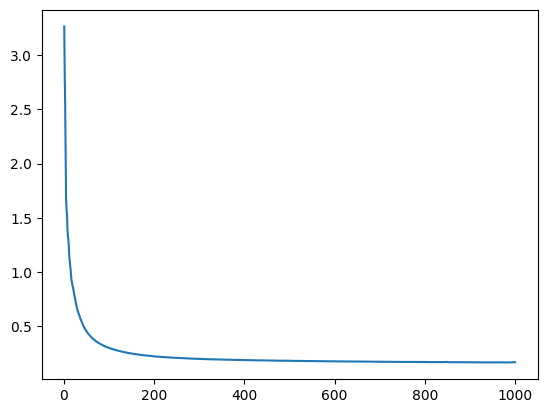

Completion of training


sh: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
sh: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
During startup - Warning messages:
1: Setting LC_CTYPE failed, using "C" 
2: Setting LC_COLLATE failed, using "C" 
3: Setting LC_TIME failed, using "C" 
4: Setting LC_MESSAGES failed, using "C" 
5: Setting LC_MONETARY failed, using "C" 
6: Setting LC_PAPER failed, using "C" 
7: Setting LC_MEASUREMENT failed, using "C" 
R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
ARI and NMI for slice 151507: 0.5102141724426903, 0.6607829676993654, 0.6559450227548256, 0.6656928077655653


/tmp/ipykernel_1907938/2856728283.py:45: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['ARI']=ARI
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


=============原始151508切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 4384 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
=============预处理后151508切片信息===============
AnnData object with n_obs × n_vars = 4384 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'
spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (4384, 3000)
AnnData object with n_obs × n_vars = 4384 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances'

...

 81%|████████  | 812/1000 [00:12<00:02, 66.11it/s]

 epoch:  800  feat_loss = 0.17  loss_sl_1 = 0.05  loss_sl_2 = 0.01  total_loss = 0.18


 91%|█████████ | 910/1000 [00:13<00:01, 65.97it/s]

 epoch:  900  feat_loss = 0.17  loss_sl_1 = 0.04  loss_sl_2 = 0.01  total_loss = 0.18


100%|██████████| 1000/1000 [00:15<00:00, 66.15it/s]


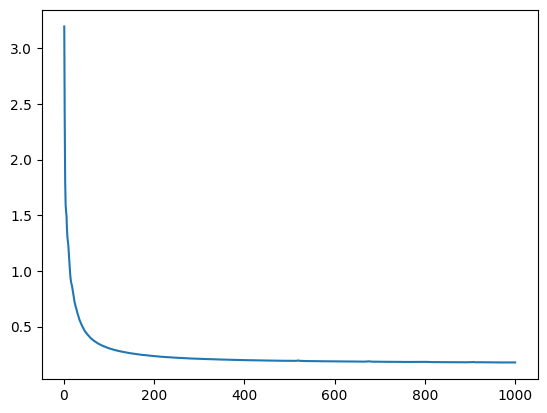

Completion of training
fitting ...
  |======================================================================| 100%
ARI and NMI for slice 151508: 0.4725007458456498, 0.6646259524407776, 0.6568719673435507, 0.6725651867115984


/tmp/ipykernel_1907938/2856728283.py:45: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['ARI']=ARI
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


=============原始151509切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 4789 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
=============预处理后151509切片信息===============
AnnData object with n_obs × n_vars = 4789 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'
spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (4789, 3000)
AnnData object with n_obs × n_vars = 4789 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances'

  1%|          | 6/1000 [00:00<00:17, 57.53it/s]

 epoch:  0  feat_loss = 1.04  loss_sl_1 = 9.10  loss_sl_2 = 0.75  total_loss = 3.01


...

 81%|████████  | 810/1000 [00:14<00:03, 57.58it/s]

 epoch:  800  feat_loss = 0.16  loss_sl_1 = 0.07  loss_sl_2 = 0.01  total_loss = 0.18


 91%|█████████ | 912/1000 [00:15<00:01, 57.50it/s]

 epoch:  900  feat_loss = 0.16  loss_sl_1 = 0.06  loss_sl_2 = 0.01  total_loss = 0.18


100%|██████████| 1000/1000 [00:17<00:00, 57.53it/s]


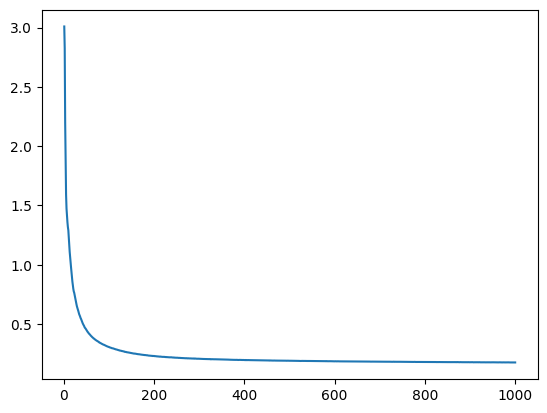

Completion of training
fitting ...
  |======================================================================| 100%
ARI and NMI for slice 151509: 0.4987823333356011, 0.6692411532391912, 0.6941171911517223, 0.6460864591090795


/tmp/ipykernel_1907938/2856728283.py:45: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['ARI']=ARI
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


=============原始151510切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 4634 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
=============预处理后151510切片信息===============
AnnData object with n_obs × n_vars = 4634 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'
spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (4634, 3000)
AnnData object with n_obs × n_vars = 4634 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances'

  1%|          | 7/1000 [00:00<00:16, 60.89it/s]

 epoch:  0  feat_loss = 1.21  loss_sl_1 = 9.04  loss_sl_2 = 0.62  total_loss = 3.14


...

 81%|████████  | 812/1000 [00:13<00:03, 61.11it/s]

 epoch:  800  feat_loss = 0.16  loss_sl_1 = 0.06  loss_sl_2 = 0.01  total_loss = 0.17


 91%|█████████ | 910/1000 [00:14<00:01, 61.11it/s]

 epoch:  900  feat_loss = 0.16  loss_sl_1 = 0.05  loss_sl_2 = 0.01  total_loss = 0.17


100%|██████████| 1000/1000 [00:16<00:00, 61.10it/s]


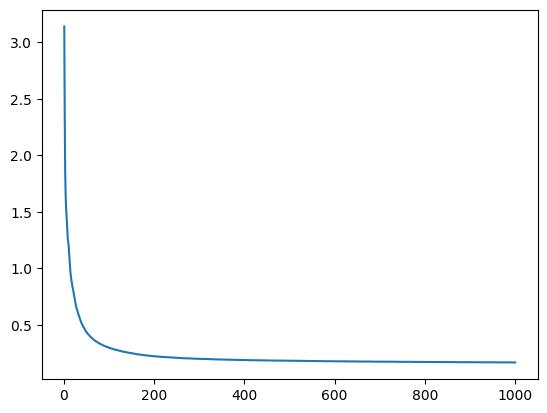

Completion of training
fitting ...
  |======================================================================| 100%
ARI and NMI for slice 151510: 0.5074189882636044, 0.6465418818608973, 0.6665935590989953, 0.6276613181433877


/tmp/ipykernel_1907938/2856728283.py:45: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['ARI']=ARI
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


=============原始151669切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 3661 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
=============预处理后151669切片信息===============
AnnData object with n_obs × n_vars = 3661 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'
spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (3661, 3000)
AnnData object with n_obs × n_vars = 3661 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances'

  1%|          | 9/1000 [00:00<00:12, 81.68it/s]

 epoch:  0  feat_loss = 1.01  loss_sl_1 = 12.54  loss_sl_2 = 0.02  total_loss = 3.52


...

 81%|████████  | 810/1000 [00:09<00:02, 85.83it/s]

 epoch:  800  feat_loss = 0.14  loss_sl_1 = 0.08  loss_sl_2 = 0.01  total_loss = 0.16


 91%|█████████ | 909/1000 [00:10<00:01, 85.77it/s]

 epoch:  900  feat_loss = 0.14  loss_sl_1 = 0.07  loss_sl_2 = 0.01  total_loss = 0.15


100%|██████████| 1000/1000 [00:11<00:00, 85.78it/s]


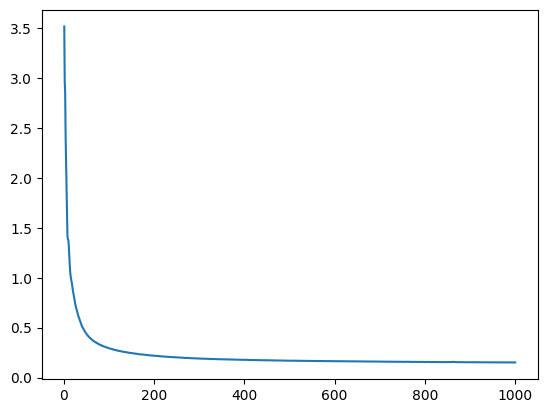

Completion of training
fitting ...
  |======================================================================| 100%
ARI and NMI for slice 151669: 0.5030567289473639, 0.6299174900871322, 0.684875566879127, 0.5831244656160545


/tmp/ipykernel_1907938/2856728283.py:45: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['ARI']=ARI
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


=============原始151670切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 3498 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
=============预处理后151670切片信息===============
AnnData object with n_obs × n_vars = 3498 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'
spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (3498, 3000)
AnnData object with n_obs × n_vars = 3498 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances'

  1%|          | 10/1000 [00:00<00:10, 91.19it/s]

 epoch:  0  feat_loss = 1.07  loss_sl_1 = 11.23  loss_sl_2 = 0.15  total_loss = 3.35


...

 81%|████████  | 810/1000 [00:08<00:01, 95.42it/s]

 epoch:  800  feat_loss = 0.15  loss_sl_1 = 0.07  loss_sl_2 = 0.01  total_loss = 0.16


 91%|█████████ | 910/1000 [00:09<00:00, 95.47it/s]

 epoch:  900  feat_loss = 0.15  loss_sl_1 = 0.06  loss_sl_2 = 0.01  total_loss = 0.16


100%|██████████| 1000/1000 [00:10<00:00, 95.46it/s]


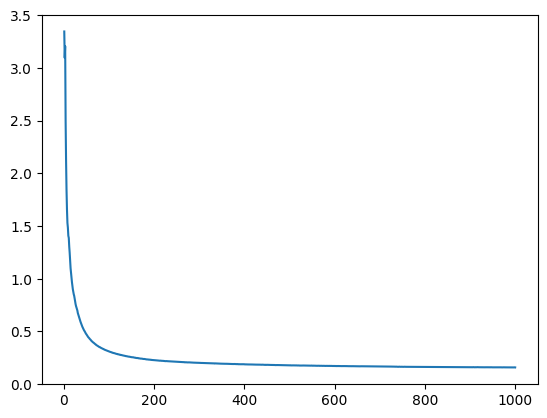

Completion of training
fitting ...
  |======================================================================| 100%
ARI and NMI for slice 151670: 0.4895631954741606, 0.6156434743313796, 0.6904258264362417, 0.5554777986896408


/tmp/ipykernel_1907938/2856728283.py:45: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['ARI']=ARI
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


=============原始151671切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 4110 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
=============预处理后151671切片信息===============
AnnData object with n_obs × n_vars = 4110 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'
spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (4110, 3000)
AnnData object with n_obs × n_vars = 4110 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances'

  1%|          | 8/1000 [00:00<00:13, 71.34it/s]

 epoch:  0  feat_loss = 1.13  loss_sl_1 = 9.29  loss_sl_2 = 0.61  total_loss = 3.11


...

 81%|████████  | 808/1000 [00:11<00:02, 72.82it/s]

 epoch:  800  feat_loss = 0.14  loss_sl_1 = 0.09  loss_sl_2 = 0.01  total_loss = 0.16


 91%|█████████ | 912/1000 [00:12<00:01, 72.81it/s]

 epoch:  900  feat_loss = 0.14  loss_sl_1 = 0.07  loss_sl_2 = 0.01  total_loss = 0.15


100%|██████████| 1000/1000 [00:13<00:00, 72.81it/s]


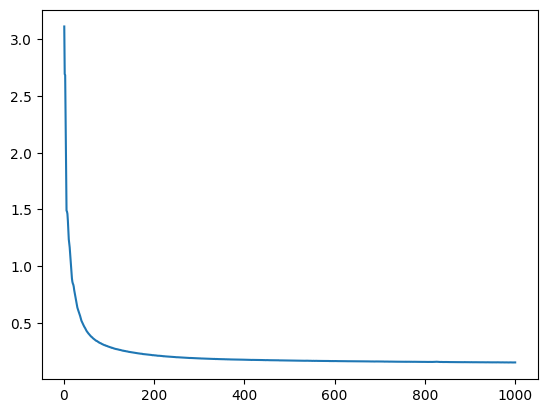

Completion of training
fitting ...
  |======================================================================| 100%
ARI and NMI for slice 151671: 0.6009320890540935, 0.7152432077369472, 0.7600123025135873, 0.6754550229412493


/tmp/ipykernel_1907938/2856728283.py:45: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['ARI']=ARI
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


=============原始151672切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 4015 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
=============预处理后151672切片信息===============
AnnData object with n_obs × n_vars = 4015 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'
spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (4015, 3000)
AnnData object with n_obs × n_vars = 4015 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances'

  1%|          | 8/1000 [00:00<00:13, 74.76it/s]

 epoch:  0  feat_loss = 0.87  loss_sl_1 = 11.86  loss_sl_2 = 0.07  total_loss = 3.26


...

 81%|████████  | 808/1000 [00:10<00:02, 76.18it/s]

 epoch:  800  feat_loss = 0.14  loss_sl_1 = 0.08  loss_sl_2 = 0.01  total_loss = 0.16


 91%|█████████ | 912/1000 [00:11<00:01, 75.96it/s]

 epoch:  900  feat_loss = 0.14  loss_sl_1 = 0.07  loss_sl_2 = 0.01  total_loss = 0.16


100%|██████████| 1000/1000 [00:13<00:00, 76.07it/s]


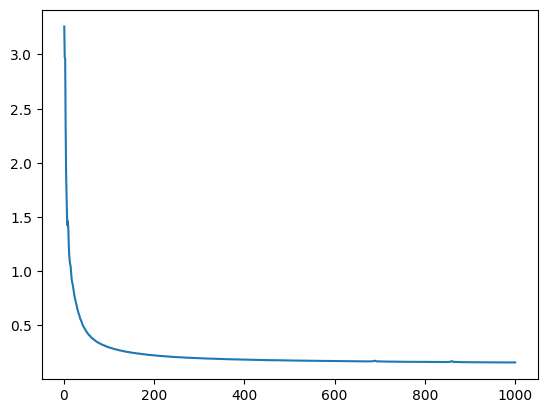

Completion of training
fitting ...
  |======================================================================| 100%
ARI and NMI for slice 151672: 0.5793394592048794, 0.6914643526015638, 0.7201357765462268, 0.6649885553829142


/tmp/ipykernel_1907938/2856728283.py:45: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['ARI']=ARI
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


=============原始151673切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
=============预处理后151673切片信息===============
AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'
spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (3639, 3000)
AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances'

  1%|          | 9/1000 [00:00<00:11, 83.42it/s]

 epoch:  0  feat_loss = 1.00  loss_sl_1 = 10.80  loss_sl_2 = 0.06  total_loss = 3.18


...

 81%|████████  | 810/1000 [00:09<00:02, 86.94it/s]

 epoch:  800  feat_loss = 0.14  loss_sl_1 = 0.06  loss_sl_2 = 0.01  total_loss = 0.16


 91%|█████████ | 909/1000 [00:10<00:01, 86.65it/s]

 epoch:  900  feat_loss = 0.14  loss_sl_1 = 0.05  loss_sl_2 = 0.01  total_loss = 0.15


100%|██████████| 1000/1000 [00:11<00:00, 86.79it/s]


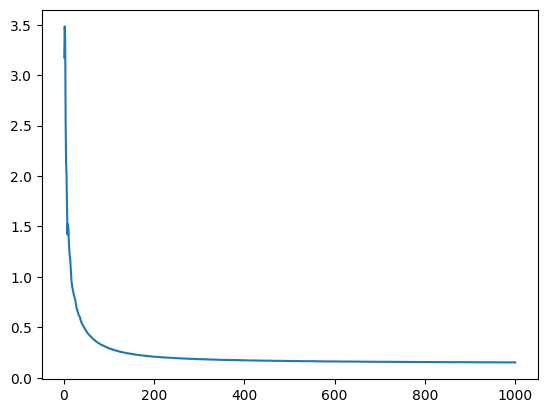

Completion of training
fitting ...
  |======================================================================| 100%
ARI and NMI for slice 151673: 0.6309972207876174, 0.7380078998539996, 0.7585207391177207, 0.7185753133196501


/tmp/ipykernel_1907938/2856728283.py:45: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['ARI']=ARI
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


=============原始151674切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 3673 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
=============预处理后151674切片信息===============
AnnData object with n_obs × n_vars = 3673 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'
spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (3673, 3000)
AnnData object with n_obs × n_vars = 3673 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances'

  1%|          | 9/1000 [00:00<00:11, 83.15it/s]

 epoch:  0  feat_loss = 1.16  loss_sl_1 = 12.45  loss_sl_2 = 0.02  total_loss = 3.65


...

 81%|████████  | 809/1000 [00:09<00:02, 85.55it/s]

 epoch:  800  feat_loss = 0.13  loss_sl_1 = 0.07  loss_sl_2 = 0.01  total_loss = 0.14


 92%|█████████▏| 917/1000 [00:10<00:00, 85.55it/s]

 epoch:  900  feat_loss = 0.12  loss_sl_1 = 0.06  loss_sl_2 = 0.01  total_loss = 0.14


100%|██████████| 1000/1000 [00:11<00:00, 84.85it/s]


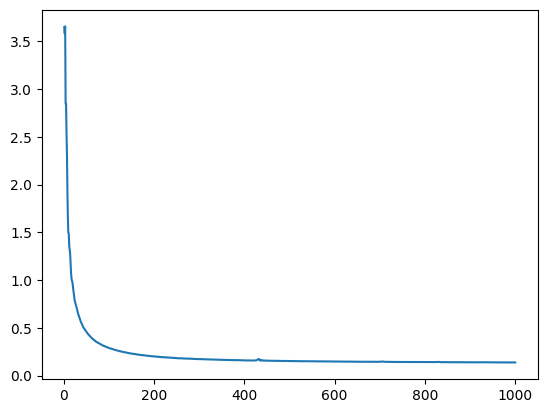

Completion of training
fitting ...
  |======================================================================| 100%
ARI and NMI for slice 151674: 0.623057022073571, 0.7207584598997296, 0.7336699802665626, 0.7082935280380813


/tmp/ipykernel_1907938/2856728283.py:45: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['ARI']=ARI
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


=============原始151675切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 3592 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
=============预处理后151675切片信息===============
AnnData object with n_obs × n_vars = 3592 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'
spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (3592, 3000)
AnnData object with n_obs × n_vars = 3592 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances'

  1%|          | 9/1000 [00:00<00:11, 85.23it/s]

 epoch:  0  feat_loss = 1.18  loss_sl_1 = 9.48  loss_sl_2 = 0.29  total_loss = 3.13


...

 81%|████████  | 810/1000 [00:09<00:02, 88.48it/s]

 epoch:  800  feat_loss = 0.16  loss_sl_1 = 0.05  loss_sl_2 = 0.01  total_loss = 0.17


 92%|█████████▏| 918/1000 [00:10<00:00, 88.33it/s]

 epoch:  900  feat_loss = 0.16  loss_sl_1 = 0.05  loss_sl_2 = 0.01  total_loss = 0.17


100%|██████████| 1000/1000 [00:11<00:00, 88.35it/s]


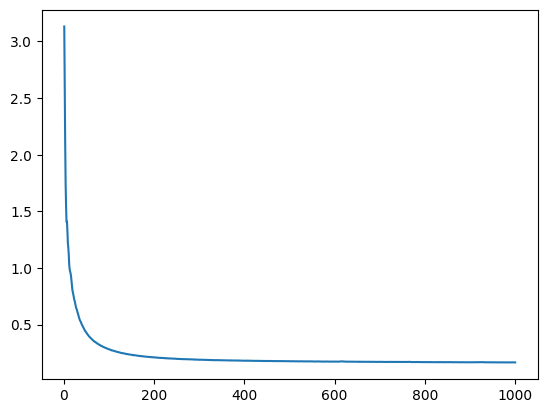

Completion of training
fitting ...
  |======================================================================| 100%
ARI and NMI for slice 151675: 0.6257297838712728, 0.7140189393590375, 0.7206279452964194, 0.7075300564693258


/tmp/ipykernel_1907938/2856728283.py:45: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['ARI']=ARI
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


=============原始151676切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 3460 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
=============预处理后151676切片信息===============
AnnData object with n_obs × n_vars = 3460 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'
spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (3460, 3000)
AnnData object with n_obs × n_vars = 3460 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances'

  1%|          | 9/1000 [00:00<00:11, 87.79it/s]

 epoch:  0  feat_loss = 1.01  loss_sl_1 = 10.22  loss_sl_2 = 0.13  total_loss = 3.08


...

 82%|████████▏ | 819/1000 [00:08<00:01, 96.12it/s]

 epoch:  800  feat_loss = 0.15  loss_sl_1 = 0.05  loss_sl_2 = 0.01  total_loss = 0.16


 92%|█████████▏| 919/1000 [00:09<00:00, 95.96it/s]

 epoch:  900  feat_loss = 0.15  loss_sl_1 = 0.04  loss_sl_2 = 0.01  total_loss = 0.16


100%|██████████| 1000/1000 [00:10<00:00, 95.45it/s]


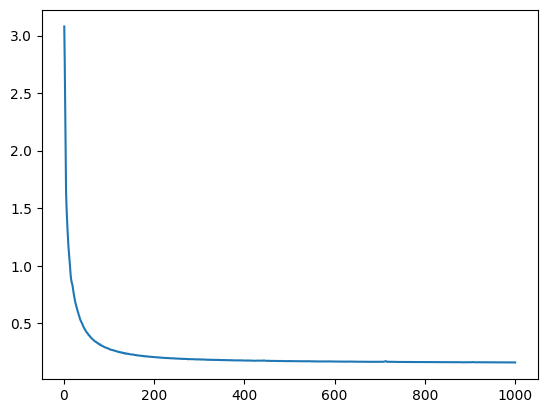

Completion of training
fitting ...
  |======================================================================| 100%
ARI and NMI for slice 151676: 0.5816334331458445, 0.6921900028544116, 0.6978348674669892, 0.6866357293279486


/tmp/ipykernel_1907938/2856728283.py:45: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['ARI']=ARI


[{'slice_id': '151507', 'ARI': 0.5102141724426903, 'NMI': 0.6607829676993654, 'HS': 0.6559450227548256, 'CS': 0.6656928077655653}, {'slice_id': '151508', 'ARI': 0.4725007458456498, 'NMI': 0.6646259524407776, 'HS': 0.6568719673435507, 'CS': 0.6725651867115984}, {'slice_id': '151509', 'ARI': 0.4987823333356011, 'NMI': 0.6692411532391912, 'HS': 0.6941171911517223, 'CS': 0.6460864591090795}, {'slice_id': '151510', 'ARI': 0.5074189882636044, 'NMI': 0.6465418818608973, 'HS': 0.6665935590989953, 'CS': 0.6276613181433877}, {'slice_id': '151669', 'ARI': 0.5030567289473639, 'NMI': 0.6299174900871322, 'HS': 0.684875566879127, 'CS': 0.5831244656160545}, {'slice_id': '151670', 'ARI': 0.4895631954741606, 'NMI': 0.6156434743313796, 'HS': 0.6904258264362417, 'CS': 0.5554777986896408}, {'slice_id': '151671', 'ARI': 0.6009320890540935, 'NMI': 0.7152432077369472, 'HS': 0.7600123025135873, 'CS': 0.6754550229412493}, {'slice_id': '151672', 'ARI': 0.5793394592048794, 'NMI': 0.6914643526015638, 'HS': 0.72013

In [4]:


for sample_name in slice_idx:
    arg.n_domain = 5 if sample_name in ['151669', '151670', '151671', '151672'] else 7
    ## loading data
    adata = read_data(data_root, sample_name)

    ## add ground truth
    df_meta = pd.read_csv(data_root / sample_name / 'metadata.tsv', sep='\t')
    adata.obs['Ground Truth'] = df_meta['layer_guess']

    adata_list_raw.append(copy.deepcopy(adata)) ## 创建一个adata的深层副本并添加到列表中
    print("=============原始{}切片信息，带ground truth===============".format(sample_name))
    print(adata)

    #preprocessing
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=arg.hvg_n)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    # sc.pp.scale(adata)
    print("=============预处理后{}切片信息===============".format(sample_name))
    print(adata)


    # train model
    adata = train(adata,arg)
    print("Completion of training")
    adata_list_after_training.append(adata)
    #
    #
    # clustering
    # adata = mclust_R(adata, arg.n_domain,used_obsm='stCCL' )
    # adata = mclust_R(adata, arg.n_domain,used_obsm='stCCL' ,refine=False)
    adata = mclust_R(adata, arg.n_domain,used_obsm='stCCL' ,refine=True)
#
    # filter out NA nodes
    adata = adata[~pd.isnull(adata.obs['Ground Truth'])]
    ARI = adjusted_rand_score(adata.obs['mclust'], adata.obs['Ground Truth'])
    NMI = normalized_mutual_info_score(adata.obs['mclust'], adata.obs['Ground Truth'])
    HS = homogeneity_score(adata.obs['Ground Truth'],adata.obs['mclust'])
    CS = completeness_score(adata.obs['Ground Truth'],adata.obs['mclust'])

    print(f"ARI and NMI for slice {sample_name}: {ARI}, {NMI}, {HS}, {CS}")
    results.append({'slice_id': sample_name, 'ARI': ARI, 'NMI': NMI, 'HS': HS,'CS': CS})
    # print('ARI = %.4f' %ARI)
    # result_ARI.append(ARI)
    adata.uns['ARI']=ARI
    adata.uns['NMI']=NMI
    adata.uns['HS']=HS
    adata.uns['CS']=CS

    adata_list_after_clustering.append(adata)
#
print(results)



In [5]:
results_df = pd.DataFrame(results)
print(results_df)

# 计算平均值
average_ARI = sum(results_df['ARI']) / len(results_df)
average_NMI = sum(results_df['NMI']) / len(results_df)
average_HS = sum(results_df['HS']) / len(results_df)
average_CS = sum(results_df['CS']) / len(results_df)
print("ARI平均值：", average_ARI)
print("NMI平均值：", average_NMI)
print("HS平均值：", average_HS)
print("CS平均值：", average_CS)

# 构造平均值行：slice_id 设为 'avg'，数值列为对应平均值
avg_row = pd.DataFrame({
    'slice_id': ['avg'],                     # 第一列标识
    'ARI': [average_ARI],
    'NMI': [average_NMI],
    'HS': [average_HS],
    'CS': [average_CS]
})

# 合并数据
results_with_avg = pd.concat([results_df, avg_row], ignore_index=True)

# 动态生成 Sheet 名称（例如 'para=0.4'）
sheet_name = f'epoch={1000}'

# 写入 Excel，使用追加模式
file_path = os.path.join(result_path, 'stCCL_DLPFC_ARI_NMI_HS_CS.xlsx')
with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    results_with_avg.to_excel(writer, sheet_name=sheet_name, index=False)

   slice_id       ARI       NMI        HS        CS
0    151507  0.510214  0.660783  0.655945  0.665693
1    151508  0.472501  0.664626  0.656872  0.672565
2    151509  0.498782  0.669241  0.694117  0.646086
3    151510  0.507419  0.646542  0.666594  0.627661
4    151669  0.503057  0.629917  0.684876  0.583124
5    151670  0.489563  0.615643  0.690426  0.555478
6    151671  0.600932  0.715243  0.760012  0.675455
7    151672  0.579339  0.691464  0.720136  0.664989
8    151673  0.630997  0.738008  0.758521  0.718575
9    151674  0.623057  0.720758  0.733670  0.708294
10   151675  0.625730  0.714019  0.720628  0.707530
11   151676  0.581633  0.692190  0.697835  0.686636
ARI平均值： 0.5519354310371957
NMI平均值： 0.6798696484970361
HS平均值： 0.7033025620726642
CS平均值： 0.6593405201262078


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/tools/_paga.py:121: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['paga'] = {}


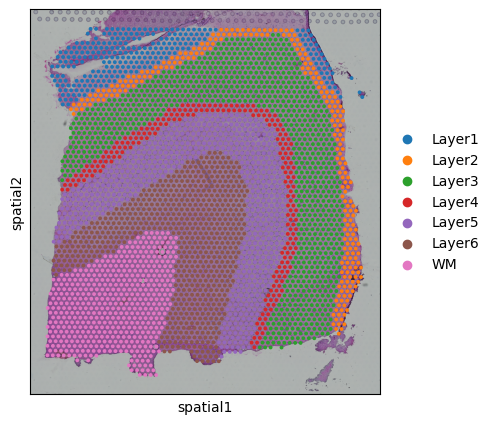

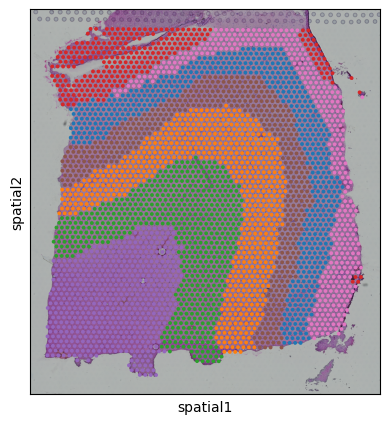

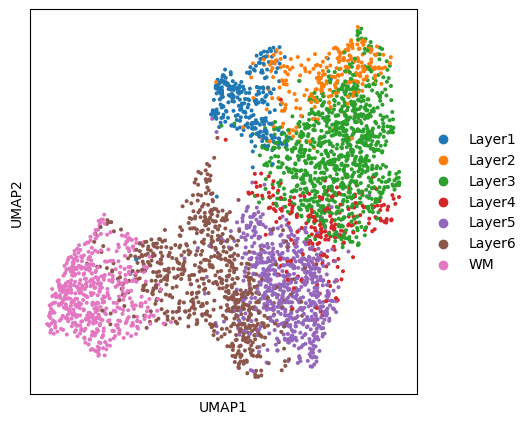

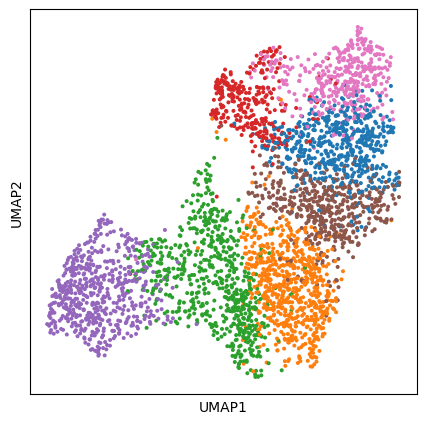

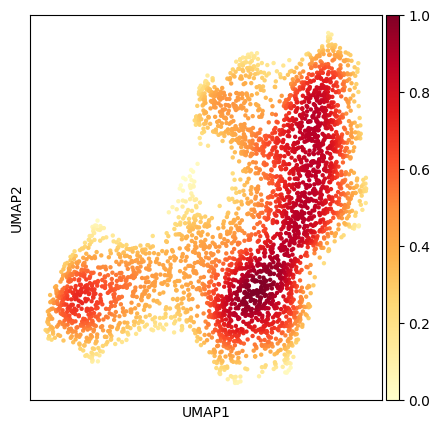

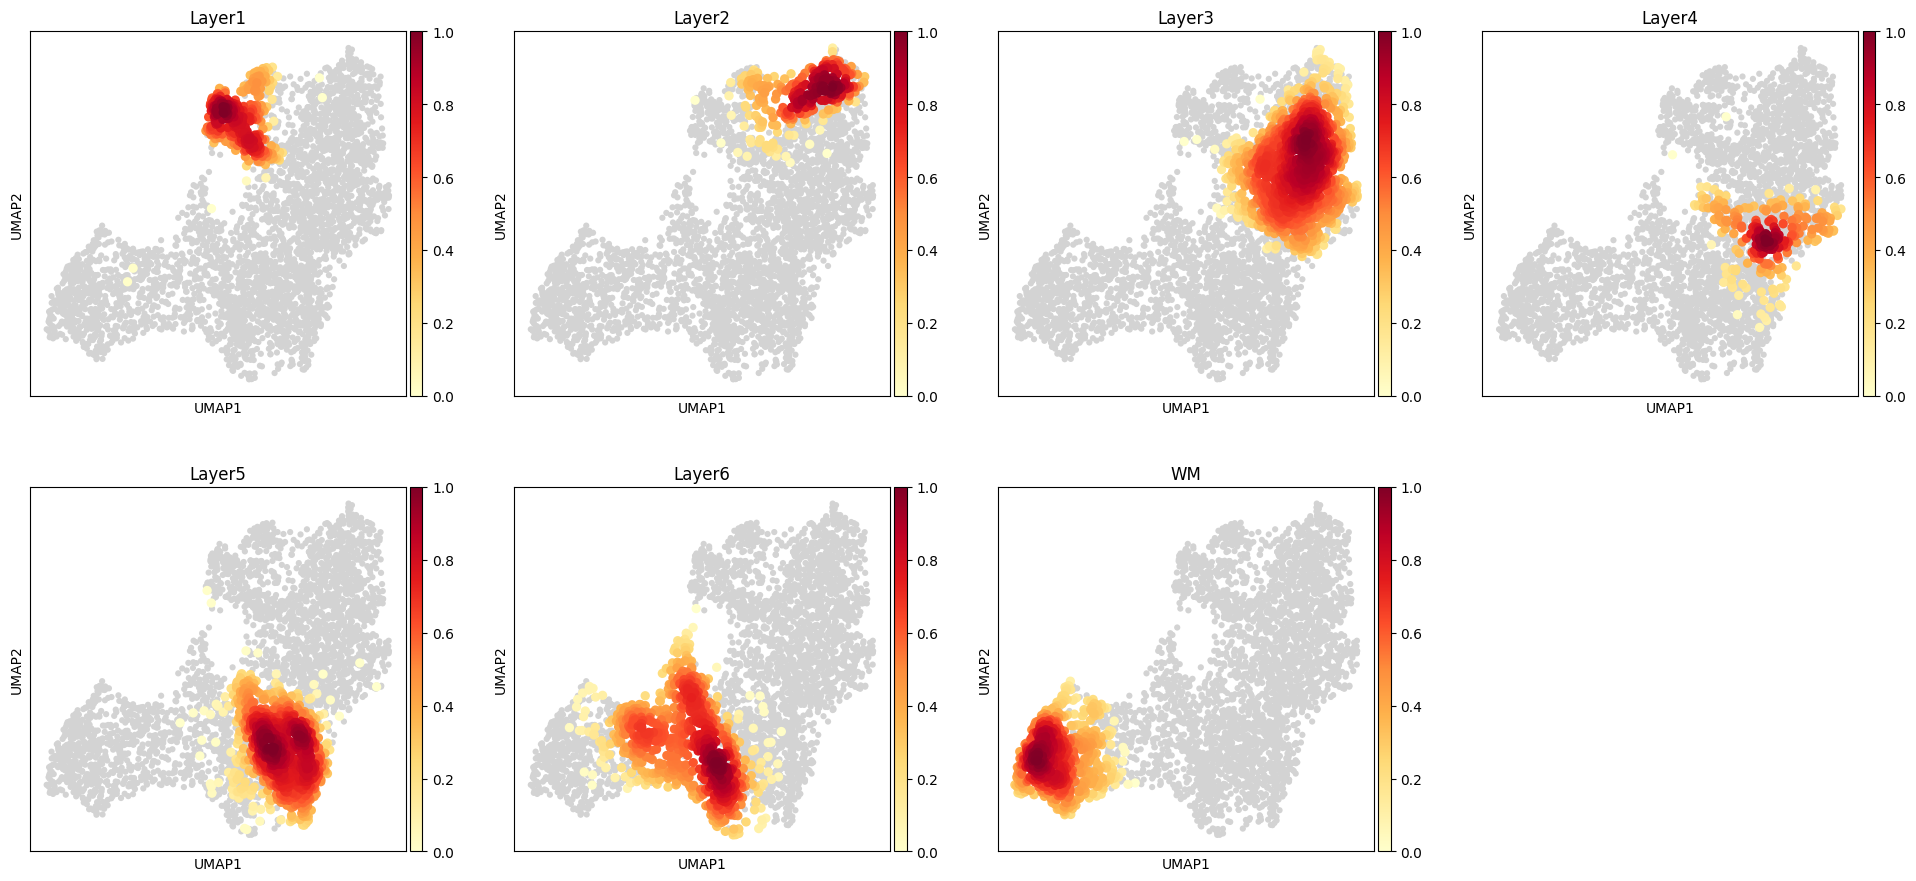

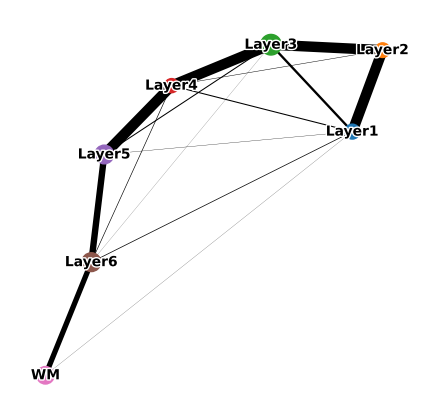

In [5]:
####可视化
# # # plotting spatial clustering result
file_path = '/home/ZHX/code111/GraphST-main/'
file_path= os.path.join(file_path, 'final_result/stCCL_result/DLPFC_refined/')
# file_path= os.path.join(file_path, 'results/MVInfoNCE2_result/DLPFC/no_refine/')
for adata in adata_list_after_clustering:
    out_path = os.path.join(result_path , adata.obs['slice_id'].unique()[0])
    # 检查文件夹是否存在，如果不存在则创建文件夹
    if not os.path.exists(out_path):
        os.makedirs(out_path)

    ## spatial architectures
    plt.rcParams["figure.figsize"] = (5, 5)
    sc.pl.spatial(adata,
                  img_key="hires",
                  color="Ground Truth",
                  title='',
                  show=False)
    plt.savefig(os.path.join(out_path,"{}_ground truth.png").format(adata.obs['slice_id'].unique()[0]),bbox_inches='tight',dpi=300)

    # if adata.obs['mclust'].nunique()==7:
    #     plot_color=[ "#d62728", "#9467bd","#e377c2", "#8c564b", "#ff7f0e", "#2ca02c","#1f77b4" ]
    # else:
    #     plot_color=[ "#1f77b4","#2ca02c","#d62728", "#9467bd", "#ff7f0e"  ]
    plt.rcParams["figure.figsize"] = (5, 5)
    sc.pl.spatial(adata,
                  img_key="hires",
                  color="mclust",
                  title='',
                  legend_loc='none',
                  # palette=plot_color,
                  show=False)
    plt.savefig(os.path.join(out_path,"{}_ARI.png").format(adata.obs['slice_id'].unique()[0]))


    # plotting predicted labels by UMAP
    sc.pp.neighbors(adata, use_rep='stCCL')
    sc.tl.umap(adata)
    plt.rcParams["figure.figsize"] = (5, 5)
    sc.pl.umap(adata,
               color="Ground Truth",
               title='',
               show=False)
    plt.savefig(os.path.join(out_path,"{}_ground_truth_umap.png").format(adata.obs['slice_id'].unique()[0]))

    plt.rcParams["figure.figsize"] = (5, 5)
    sc.pl.umap(adata,
               color="mclust",
               title='',
               legend_loc='none',
               show=False)
    plt.savefig(os.path.join(out_path,"{}_umap.png").format(adata.obs['slice_id'].unique()[0]))


    ## heatmap of density
    plt.rcParams["figure.figsize"] = (5, 5)
    sc.tl.embedding_density(adata, basis='umap')
    sc.pl.embedding_density(adata, basis='umap', fg_dotsize=40, show=False)
    plt.savefig(os.path.join(out_path,"{}_heatmap of density.png").format(adata.obs['slice_id'].unique()[0]))

    plt.rcParams["figure.figsize"] = (5, 5)
    sc.tl.embedding_density(adata, basis='umap', groupby='Ground Truth')
    sc.pl.embedding_density(adata, basis='umap', groupby='Ground Truth', show=False)
    plt.savefig(os.path.join(out_path,"{}_heatmap of density_by_layer.png").format(adata.obs['slice_id'].unique()[0]))

    ## paga trajectory inference
    adata = adata[adata.obs['Ground Truth'].notna(), :]
    sc.tl.paga(adata, groups='Ground Truth')
    plt.rcParams["figure.figsize"] = (5, 5)
    # 绘制标准PAGA图 (替换了paga_compare)
    sc.pl.paga(adata,show=False,  frameon=False,fontsize=10,  fontoutline=2)
    plt.savefig(os.path.join(out_path,"{}_paga.png").format(adata.obs['slice_id'].unique()[0]))

    # plt.rcParams["figure.figsize"] = (5, 5)
    # # 绘制标准PAGA图 (替换了paga_compare)
    # sc.pl.paga(adata,show=False, fontsize=10,  fontoutline=2)
    # plt.savefig(os.path.join(out_path,"{}_paga_frame.png").format(adata.obs['slice_id'].unique()[0]))

    # ## paga trajectory inference
    # adata = adata[adata.obs['Ground Truth'].notna(), :]
    # sc.tl.paga(adata, groups='Ground Truth')
    # plt.rcParams["figure.figsize"] = (5, 5)
    # sc.pl.paga_compare(adata, legend_fontsize=10, frameon=False, size=50,
    #                    title=adata.obs['slice_id'].unique()[0] + '-stCCL', legend_fontoutline=2, show=False)
    # plt.savefig(os.path.join(out_path,"{}_paga.png").format(adata.obs['slice_id'].unique()[0]))
